In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import numpy as np
from datasets import load_dataset, concatenate_datasets
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import Whitespace
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import time
import os
import re
import json
from itertools import groupby
import random
from torch.utils.checkpoint import checkpoint

In [2]:
# Disable tokenizer parallelism
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ===================== Enhanced Configuration =====================
D_MODEL = 512        # Model dimension
D_K = 256              # Attention key dimension (must be even)
FF_DIM = 3056          # Feed-forward dimension
NUM_LAYERS = 6        # Number of decoder layers
VOCAB_SIZE = 30000     # Vocabulary size
SEQ_LEN = 256          # Sequence length
BATCH_SIZE = 64        # Batch size
NUM_EPOCHS = 3        # Training epochs
LR = 3e-4              # Learning rate
DROPOUT = 0.2          # Dropout rate
WEIGHT_DECAY = 0.05    # Weight decay
GRAD_CLIP = 1.0        # Gradient clipping
WARMUP_STEPS = 4000    # Warmup steps
GRAD_ACCUM_STEPS = 4   # Gradient accumulation steps
PATIENCE = 5           # Early stopping patience
GRAD_CHECKPOINT = True # Enable gradient checkpointing for memory savings
CONV_SPECIAL_TOKENS = ["[PAD]", "[UNK]", "[BOS]", "[EOS]", "[SPK1]", "[SPK2]"]  # Speaker tokens


In [3]:
# Dataset sampling ratios (balance between datasets)
DATASET_RATIOS = {
    "daily_dialog": 0.1,
    "empathetic_dialogues": 0.2,
    "ultrachat": 0.7
}

# ===================== Very Large Dataset Loading =====================
# ===================== Very Large Dataset Loading =====================
print("Loading very large conversational datasets...")

# Load DailyDialog dataset
daily_dialog = load_dataset("daily_dialog", revision="refs/convert/parquet")

# Load EmpatheticDialogues dataset
empathetic_dialogues = load_dataset(
    "empathetic_dialogues",
    revision="refs/convert/parquet"
)

# Load massive UltraChat dataset (1.5M dialogues) in streaming mode
from datasets import load_dataset

# Load without streaming
ultrachat_large = load_dataset("HuggingFaceH4/ultrachat_200k", split="train_gen")

# Select first 100k samples
ultrachat = ultrachat_large.select(range(20_000))

print("Datasets loaded successfully!")

Loading very large conversational datasets...


0000.parquet:   0%|          | 0.00/3.61M [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/334k [00:00<?, ?B/s]

0000.parquet:   0%|          | 0.00/331k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

...

Generating train_sft split:   0%|          | 0/207865 [00:00<?, ? examples/s]

Generating test_sft split:   0%|          | 0/23110 [00:00<?, ? examples/s]

Generating train_gen split:   0%|          | 0/256032 [00:00<?, ? examples/s]

Generating test_gen split:   0%|          | 0/28304 [00:00<?, ? examples/s]

Datasets loaded successfully!


In [4]:
# ===================== Dataset Processing Functions =====================
def extract_empathetic_conversations(dataset):
    """Extract conversations from EmpatheticDialogues dataset"""
    conversations = []
    sorted_data = sorted(dataset, key=lambda x: x['conv_id'])
    for _, group in groupby(sorted_data, key=lambda x: x['conv_id']):
        utterances = [item['utterance'] for item in group]
        conversations.append(utterances)
    return conversations

def extract_ultrachat_conversations(data):
    """Extract conversations from UltraChat dataset"""
    conversations = []
    for sample in data:
        # UltraChat stores conversations as list of messages
        conv = []
        for msg in sample["messages"]:
            if msg["role"] == "user":
                conv.append(msg["content"])
            elif msg["role"] == "assistant":
                conv.append(msg["content"])
        conversations.append(conv)
    return conversations

def clean_text(text):
    """Robust text cleaning"""
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')
    text = re.sub(r'\[\d+\]', '', text)  # Remove citations
    text = re.sub(r'\[.*?\]', '', text)   # Remove other brackets
    text = re.sub(r'\s+', ' ', text)      # Collapse whitespace
    text = re.sub(r'[^\w\s.,;:?!\'"-]', '', text)  # Remove special chars
    return text.strip()

In [5]:
from itertools import islice
import random

# Desired sizes for final balanced dataset
TARGET_TRAIN_PER_SOURCE = 16_000  # or whatever you want
TARGET_VAL_PER_SOURCE = 4_000

def create_balanced_dataset():
    """Create balanced dataset with fixed per-source sizes"""
    train_convs = []
    val_convs = []
    
    # ---------------- DailyDialog ----------------
    daily_train = random.sample(daily_dialog["train"]["dialog"], min(TARGET_TRAIN_PER_SOURCE, len(daily_dialog["train"])))
    daily_val = random.sample(daily_dialog["validation"]["dialog"], min(TARGET_VAL_PER_SOURCE, len(daily_dialog["validation"])))
    print(f"DailyDialog: {len(daily_train)} train, {len(daily_val)} val")
    
    # ---------------- EmpatheticDialogues ----------------
    emp_train_all = extract_empathetic_conversations(empathetic_dialogues["train"])
    emp_val_all = extract_empathetic_conversations(empathetic_dialogues["validation"])
    
    emp_train = random.sample(emp_train_all, min(TARGET_TRAIN_PER_SOURCE, len(emp_train_all)))
    emp_val = random.sample(emp_val_all, min(TARGET_VAL_PER_SOURCE, len(emp_val_all)))
    print(f"EmpatheticDialogues: {len(emp_train)} train, {len(emp_val)} val")
    
    # ---------------- UltraChat (streamed + fixed size) ----------------
    ultra_train_samples = []
    ultra_val_samples = []
    
    ultra_stream = ultrachat  # already loaded in streaming mode
    
    for i, sample in enumerate(islice(ultra_stream, TARGET_TRAIN_PER_SOURCE + TARGET_VAL_PER_SOURCE)):
        if i < TARGET_TRAIN_PER_SOURCE:
            ultra_train_samples.append(sample)
        else:
            ultra_val_samples.append(sample)
    
    ultra_train = extract_ultrachat_conversations(ultra_train_samples)
    ultra_val = extract_ultrachat_conversations(ultra_val_samples)
    print(f"UltraChat: {len(ultra_train)} train, {len(ultra_val)} val")
    
    # ---------------- Combine ----------------
    train_convs = daily_train + emp_train + ultra_train
    val_convs = daily_val + emp_val + ultra_val
    
    random.shuffle(train_convs)
    random.shuffle(val_convs)
    
    print(f"Total training conversations: {len(train_convs)}")
    print(f"Total validation conversations: {len(val_convs)}")
    
    return train_convs, val_convs

train_convs, val_convs = create_balanced_dataset()


DailyDialog: 11118 train, 1000 val
EmpatheticDialogues: 16000 train, 2763 val
UltraChat: 16000 train, 4000 val
Total training conversations: 43118
Total validation conversations: 7763


In [6]:
# ===================== Efficient Tokenizer Training =====================
print("Building tokenizer for large conversational data...")

# Initialize tokenizer
tokenizer = Tokenizer(BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = Whitespace()
trainer = BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=CONV_SPECIAL_TOKENS,
    min_frequency=2,
    show_progress=True
)

# Generator for streaming text data
def batch_iterator(batch_size=10000):
    """Efficient batch iterator for large datasets"""
    for i in range(0, len(train_convs), batch_size):
        batch = train_convs[i:i+batch_size]
        texts = []
        for conv in batch:
            cleaned_conv = [clean_text(utterance) for utterance in conv]
            cleaned_conv = [text for text in cleaned_conv if text]
            if cleaned_conv:
                texts.append(" ".join(cleaned_conv))
        yield texts

# Train tokenizer in chunks
for batch in batch_iterator():
    tokenizer.train_from_iterator(batch, trainer=trainer, length=len(batch))

vocab_size = tokenizer.get_vocab_size()
print(f"Tokenizer vocab size: {vocab_size}")

# Save tokenizer
os.makedirs("tokenizer", exist_ok=True)
tokenizer.save("tokenizer/tokenizer.json")

Building tokenizer for large conversational data...















Tokenizer vocab size: 30000


In [7]:
# ===================== Rotary Positional Embedding (RoPE) =====================
class RotaryEmbedding(nn.Module):
    def __init__(self, dim, max_seq_len=5000):
        super().__init__()
        self.dim = dim
        self.max_seq_len = max_seq_len
        
        # Compute inverse frequencies
        inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq)
        
        # Build cache
        self._build_cache(max_seq_len)
    
    def _build_cache(self, max_seq_len):
        self.max_seq_len = max_seq_len
        t = torch.arange(max_seq_len, device=self.inv_freq.device, dtype=torch.float32)
        freqs = torch.einsum('i,j->ij', t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)
    
    def forward(self, x, seq_len=None):
        if seq_len is None:
            seq_len = x.size(1)
        if seq_len > self.max_seq_len:
            self._build_cache(seq_len)
        return (
            self.cos_cached[:seq_len].to(dtype=x.dtype),
            self.sin_cached[:seq_len].to(dtype=x.dtype),
        )

def rotate_half(x):
    """Rotate half of the dimensions"""
    x1, x2 = x.chunk(2, dim=-1)
    return torch.cat((-x2, x1), dim=-1)

def apply_rotary_emb(q, k, cos, sin):
    """Apply rotary embeddings to queries and keys"""
    q_embed = (q * cos.unsqueeze(0)) + (rotate_half(q) * sin.unsqueeze(0))
    k_embed = (k * cos.unsqueeze(0)) + (rotate_half(k) * sin.unsqueeze(0))
    return q_embed, k_embed

In [8]:
# ===================== CoupledAttention with RoPE =====================
class CoupledAttention(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        assert d_k % 2 == 0, "d_k must be even for rotary embeddings"
        self.d_k = d_k
        self.qw_proj = nn.Linear(d_model, d_k)
        self.kw_proj = nn.Linear(d_model, d_k)
        self.qp_proj = nn.Linear(d_model, d_k)
        self.kp_proj = nn.Linear(d_model, d_k)
        
        # Rotary embeddings
        self.rotary = RotaryEmbedding(d_k)
        
    def forward(self, word_embed, mask=None):
        B, L, _ = word_embed.size()
        
        # Project to queries and keys
        qw = self.qw_proj(word_embed)
        kw = self.kw_proj(word_embed)
        qp = self.qp_proj(word_embed)
        kp = self.kp_proj(word_embed)
        
        # Apply rotary embeddings
        cos, sin = self.rotary(qw, seq_len=L)
        qw, kw = apply_rotary_emb(qw, kw, cos, sin)
        qp, kp = apply_rotary_emb(qp, kp, cos, sin)
        
        # Compute attention scores
        w2p = F.silu(qw @ kp.transpose(-2, -1))
        p2w = F.silu(qp @ kw.transpose(-2, -1))
        scores = (w2p + p2w) / math.sqrt(2 * self.d_k)
        
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(1)
            scores = scores.masked_fill(mask == 0, float('-inf'))
            
        attn = F.softmax(scores, dim=-1)
        return attn @ word_embed, attn

# ===================== Enhanced Decoder Block with Gradient Checkpointing =====================
class DecoderBlock(nn.Module):
    def __init__(self, d_model, d_k, ff_dim):
        super().__init__()
        self.self_attn = CoupledAttention(d_model, d_k)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Enhanced FFN with Gated Linear Unit
        self.ffn = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.GELU(),
            nn.Dropout(DROPOUT),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(DROPOUT)
        )
        
        self.dropout1 = nn.Dropout(DROPOUT)
        self.dropout2 = nn.Dropout(DROPOUT)

    def forward(self, x, mask):
        # Gradient checkpointing for memory savings
        if GRAD_CHECKPOINT and self.training:
            attn_out = checkpoint(self._attn_block, x, mask)
        else:
            attn_out = self._attn_block(x, mask)
        
        # Feed-forward network
        ffn_out = self.ffn(attn_out)
        x = x + self.dropout2(ffn_out)
        x = self.norm2(x)
        
        return x, None  # We don't return attention weights for efficiency
    
    def _attn_block(self, x, mask):
        attn_out, _ = self.self_attn(x, mask)
        x = x + self.dropout1(attn_out)
        return self.norm1(x)

# ===================== Conversational Transformer Decoder =====================
class ConversationalTransformer(nn.Module):
    def __init__(self, num_layers, d_model, d_k, ff_dim, vocab_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.speaker_embedding = nn.Embedding(2, d_model)  # Two speakers
        
        self.layers = nn.ModuleList([
            DecoderBlock(d_model, d_k, ff_dim)
            for _ in range(num_layers)
        ])
        self.final_norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        
        # Weight tying
        self.head.weight = self.embedding.weight
        
        # Initialize weights
        self.apply(self._init_weights)
        
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.kaiming_normal_(module.weight, nonlinearity='relu')
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)
    
    def forward(self, input_ids, speaker_ids, mask=None):
        # Embeddings with speaker information
        word_embed = self.embedding(input_ids)
        speaker_embed = self.speaker_embedding(speaker_ids)
        x = word_embed + speaker_embed
        
        # Apply decoder layers
        for layer in self.layers:
            x, _ = layer(x, mask)  # We don't return attention weights for efficiency
        
        x = self.final_norm(x)
        logits = self.head(x)
        
        return logits, None  # Don't return attention weights to save memory

In [9]:
# ===================== Conversational Dataset with Streaming =====================
class ConversationDataset(Dataset):
    def __init__(self, conversations, seq_len=256, step_size=128):
        self.seq_len = seq_len
        self.step_size = step_size
        self.tokens = []
        self.speakers = []
        self.segments = []          # ADD THIS LINE
        self.speaker_segments = []  # ADD THIS LINE
        
        # Special token IDs
        self.bos_id = tokenizer.token_to_id("[BOS]")
        self.eos_id = tokenizer.token_to_id("[EOS]")
        self.pad_id = tokenizer.token_to_id("[PAD]")
        self.spk1_id = tokenizer.token_to_id("[SPK1]")
        self.spk2_id = tokenizer.token_to_id("[SPK2]")
        
        # Process conversations in chunks
        chunk_size = 10000
        for i in range(0, len(conversations), chunk_size):
            chunk = conversations[i:i+chunk_size]
            self._process_chunk(chunk)
    
    def _process_chunk(self, chunk):
        """Process a chunk of conversations"""
        for conv in chunk:
            conv_tokens = [self.bos_id]
            conv_speakers = [0]  # Default speaker for BOS
            
            speaker_idx = 0
            for utterance in conv:
                if not utterance.strip():
                    continue
                    
                # Add speaker token
                spk_token = self.spk1_id if speaker_idx == 0 else self.spk2_id
                conv_tokens.append(spk_token)
                conv_speakers.append(speaker_idx)
                
                # Tokenize utterance
                encoding = tokenizer.encode(clean_text(utterance))
                conv_tokens.extend(encoding.ids)
                conv_speakers.extend([speaker_idx] * len(encoding.ids))
                
                # Add EOS and switch speaker
                conv_tokens.append(self.eos_id)
                conv_speakers.append(speaker_idx)
                speaker_idx = 1 - speaker_idx
            
            if len(conv_tokens) > 1:
                self.tokens.extend(conv_tokens)
                self.speakers.extend(conv_speakers)
        
        # Create overlapping sequences
        for i in range(0, len(self.tokens) - self.seq_len + 1, self.step_size):
            self.segments.append(self.tokens[i:i+self.seq_len])
            self.speaker_segments.append(self.speakers[i:i+self.seq_len])
    
    def __len__(self):
        return len(self.segments)
    
    def __getitem__(self, idx):
        return (
            torch.tensor(self.segments[idx]),
            torch.tensor(self.speaker_segments[idx])
        )

# Create datasets
print("Creating training dataset...")
train_dataset = ConversationDataset(train_convs, SEQ_LEN, step_size=SEQ_LEN//2)
print("Creating validation dataset...")
val_dataset = ConversationDataset(val_convs, SEQ_LEN, step_size=SEQ_LEN)

print(f"Train sequences: {len(train_dataset)} | Val sequences: {len(val_dataset)}")

# Data loaders
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=4, 
    pin_memory=True,
    persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    num_workers=4, 
    pin_memory=True,
    persistent_workers=True
)


Creating training dataset...
Creating validation dataset...
Train sequences: 437976 | Val sequences: 15245


In [10]:
# ===================== Training Setup =====================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ConversationalTransformer(
    num_layers=NUM_LAYERS,
    d_model=D_MODEL,
    d_k=D_K,
    ff_dim=FF_DIM,
    vocab_size=vocab_size
).to(device)

# Print model size
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {num_params/1e6:.2f}M")

# Optimizer with weight decay
optimizer = torch.optim.AdamW(
    model.parameters(), 
    lr=LR, 
    betas=(0.9, 0.98),
    eps=1e-6,
    weight_decay=WEIGHT_DECAY
)

# Loss function
criterion = nn.CrossEntropyLoss(ignore_index=tokenizer.token_to_id("[PAD]"))

# Learning rate scheduler
def get_lr_scheduler(optimizer, warmup_steps, total_steps):
    def lr_lambda(current_step):
        if current_step < warmup_steps:
            return float(current_step) / float(max(1, warmup_steps))
        progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))
    
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

Using device: cuda
Model parameters: 37.35M


In [11]:
# ===================== Training Utilities =====================
def create_decoder_mask(seq_len, device):
    """Create causal mask for decoder"""
    return torch.tril(torch.ones(seq_len, seq_len, device=device)).bool()

def create_padding_mask(inputs, pad_id, device):
    """Create padding mask"""
    return (inputs != pad_id).to(device)

def generate_conversation(model, context, speaker=0, max_length=100, temperature=0.7, top_k=50, top_p=0.9):
    """Generate conversational responses"""
    model.eval()

    # Token IDs
    bos_id = tokenizer.token_to_id("[BOS]")
    eos_id = tokenizer.token_to_id("[EOS]")
    pad_id = tokenizer.token_to_id("[PAD]")
    spk1_id = tokenizer.token_to_id("[SPK1]")
    spk2_id = tokenizer.token_to_id("[SPK2]")

    tokens = [bos_id]
    speakers = [0]
    
    # Add context
    for utterance in context:
        spk_token = spk1_id if speaker == 0 else spk2_id
        tokens.append(spk_token)
        speakers.append(speaker)
        
        utterance_ids = tokenizer.encode(clean_text(utterance)).ids
        tokens.extend(utterance_ids)
        speakers.extend([speaker] * len(utterance_ids))
        
        tokens.append(eos_id)
        speakers.append(speaker)
        speaker = 1 - speaker  # alternate speakers
    
    generated = tokens.copy()
    current_speakers = speakers.copy()
    
    with torch.no_grad():
        for _ in range(max_length):
            input_tensor = torch.tensor([generated[-SEQ_LEN:]]).to(device)
            speaker_tensor = torch.tensor([current_speakers[-SEQ_LEN:]]).to(device)
            seq_len = input_tensor.size(1)
            
            # Create masks
            causal_mask = create_decoder_mask(seq_len, device)
            pad_mask = create_padding_mask(input_tensor, pad_id, device)
            mask = causal_mask.unsqueeze(0) & pad_mask.unsqueeze(1)
            
            logits, _ = model(input_tensor, speaker_tensor, mask)
            next_logits = logits[0, -1, :] / temperature
            
            # Top-k filtering
            if top_k > 0:
                top_k_logits, top_k_indices = next_logits.topk(top_k)
                min_val = top_k_logits[-1]
                next_logits[next_logits < min_val] = float('-inf')
            
            # Nucleus (top-p) filtering
            sorted_logits, sorted_indices = torch.sort(next_logits, descending=True)
            cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            sorted_indices_to_remove = cumulative_probs > top_p
            sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
            sorted_indices_to_remove[..., 0] = 0
            indices_to_remove = sorted_indices[sorted_indices_to_remove]
            next_logits[indices_to_remove] = float('-inf')
            
            # Sample next token
            probabilities = F.softmax(next_logits, dim=-1).cpu().numpy()
            next_token = np.random.choice(len(probabilities), p=probabilities)
            
            generated.append(next_token)
            current_speakers.append(speaker)
            
            if next_token == eos_id:
                break
    
    # Decode tokens into utterances
    decoded = []
    current_utterance = []
    for token in generated:
        if token in [spk1_id, spk2_id]:
            if current_utterance:
                decoded.append(tokenizer.decode(current_utterance))
                current_utterance = []
        elif token not in [bos_id, eos_id, pad_id]:
            current_utterance.append(token)
    
    if current_utterance:
        decoded.append(tokenizer.decode(current_utterance))
    
    return decoded[len(context):]


In [12]:
# ===================== Enhanced Training Loop =====================
print("Starting training...")
start_time = time.time()

# Calculate total training steps
total_steps = (NUM_EPOCHS * len(train_loader)) // GRAD_ACCUM_STEPS
scheduler = get_lr_scheduler(optimizer, WARMUP_STEPS, total_steps)

# Training statistics
train_losses = []
val_losses = []
train_ppls = []
val_ppls = []
train_accs = []
val_accs = []

best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    # Training
    model.train()
    train_loss = 0
    total_train_tokens = 0
    correct_train = 0
    epoch_start = time.time()
    optimizer.zero_grad()
    
    for batch_idx, (batch, speaker_batch) in enumerate(train_loader):
        batch = batch.to(device, non_blocking=True)
        speaker_batch = speaker_batch.to(device, non_blocking=True)
        
        # Create shifted inputs/targets
        inputs, targets = batch[:, :-1], batch[:, 1:]
        speaker_inputs = speaker_batch[:, :-1]
        seq_len = inputs.size(1)
        
        # Create masks
        causal_mask = create_decoder_mask(seq_len, device)
        pad_mask = create_padding_mask(inputs, tokenizer.token_to_id("[PAD]"), device)
        mask = causal_mask.unsqueeze(0) & pad_mask.unsqueeze(1)
        
        # Forward pass
        logits, _ = model(inputs, speaker_inputs, mask)
        
        # Calculate loss
        loss = criterion(logits.view(-1, vocab_size), targets.reshape(-1))
        loss = loss / GRAD_ACCUM_STEPS
        loss.backward()
        
        # Calculate accuracy
        with torch.no_grad():
            preds = torch.argmax(logits, dim=-1)
            valid_mask = targets != tokenizer.token_to_id("[PAD]")
            correct = (preds[valid_mask] == targets[valid_mask]).sum().item()
            total = valid_mask.sum().item()
            correct_train += correct
            total_train_tokens += total
        
        # Gradient accumulation
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0 or (batch_idx + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
        
        train_loss += loss.item() * GRAD_ACCUM_STEPS
        
        # Logging
        if batch_idx % 50 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            batch_acc = correct / total if total > 0 else 0.0
            print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx}/{len(train_loader)} | "
                  f"Loss: {loss.item() * GRAD_ACCUM_STEPS:.4f} | Acc: {batch_acc:.4f} | "
                  f"LR: {current_lr:.2e} | Time: {time.time() - start_time:.0f}s")
    
    # Validation
    model.eval()
    val_loss = 0
    total_val_tokens = 0
    correct_val = 0
    with torch.no_grad():
        for batch, speaker_batch in val_loader:
            batch = batch.to(device, non_blocking=True)
            speaker_batch = speaker_batch.to(device, non_blocking=True)
            inputs, targets = batch[:, :-1], batch[:, 1:]
            speaker_inputs = speaker_batch[:, :-1]
            seq_len = inputs.size(1)
            
            # Create masks
            causal_mask = create_decoder_mask(seq_len, device)
            pad_mask = create_padding_mask(inputs, tokenizer.token_to_id("[PAD]"), device)
            mask = causal_mask.unsqueeze(0) & pad_mask.unsqueeze(1)
            
            logits, _ = model(inputs, speaker_inputs, mask)
            loss = criterion(logits.view(-1, vocab_size), targets.reshape(-1))
            val_loss += loss.item()
            
            # Calculate accuracy
            preds = torch.argmax(logits, dim=-1)
            valid_mask = targets != tokenizer.token_to_id("[PAD]")
            correct_val += (preds[valid_mask] == targets[valid_mask]).sum().item()
            total_val_tokens += valid_mask.sum().item()
    
    # Epoch statistics
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    
    train_acc = correct_train / total_train_tokens if total_train_tokens > 0 else 0.0
    val_acc = correct_val / total_val_tokens if total_val_tokens > 0 else 0.0
    
    train_ppl = math.exp(avg_train_loss)
    val_ppl = math.exp(avg_val_loss)
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_ppls.append(train_ppl)
    val_ppls.append(val_ppl)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    epoch_time = time.time() - epoch_start
    print(f"\nEpoch {epoch+1} Summary ({epoch_time:.0f}s):")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"Train PPL: {train_ppl:.2f} | Val PPL: {val_ppl:.2f}")
    print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    # Generate sample conversation
    print("\nSample Generated Conversation:")
    context = ["What do you think about the latest AI advancements?"]
    print(f"Context: {context[0]}")
    responses = generate_conversation(model, context, max_length=100, temperature=0.8)
    for i, response in enumerate(responses):
        print(f"Response {i+1}: {response}")
    
    # Early stopping check
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model.pth")
        print(f"New best model saved with val loss: {avg_val_loss:.4f}")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve} epochs")
    
    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break
    
    # Save checkpoint
    if (epoch + 1) % 5 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_losses,
            'val_loss': val_losses,
            'train_ppl': train_ppls,
            'val_ppl': val_ppls,
            'train_acc': train_accs,
            'val_acc': val_accs
        }, f"model_epoch_{epoch+1}.pth")
        print(f"Saved model checkpoint at epoch {epoch+1}")
    
    print("-" * 80 + "\n")

total_time = time.time() - start_time
print(f"Training complete in {total_time/60:.1f} minutes!")

# Load best model
model.load_state_dict(torch.load("best_model.pth"))

Starting training...


/usr/local/lib/python3.11/dist-packages/torch/_dynamo/eval_frame.py:745: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. In version 2.5 we will raise an exception if use_reentrant is not passed. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Epoch 1/3 | Batch 0/6844 | Loss: 11.3189 | Acc: 0.0000 | LR: 0.00e+00 | Time: 2s
Epoch 1/3 | Batch 50/6844 | Loss: 11.2356 | Acc: 0.0000 | LR: 9.00e-07 | Time: 35s
Epoch 1/3 | Batch 100/6844 | Loss: 11.0866 | Acc: 0.0001 | LR: 1.87e-06 | Time: 69s
Epoch 1/3 | Batch 150/6844 | Loss: 10.8740 | Acc: 0.0007 | LR: 2.77e-06 | Time: 102s
Epoch 1/3 | Batch 200/6844 | Loss: 10.5618 | Acc: 0.0089 | LR: 3.75e-06 | Time: 136s
Epoch 1/3 | Batch 250/6844 | Loss: 10.2746 | Acc: 0.0327 | LR: 4.65e-06 | Time: 169s
Epoch 1/3 | Batch 300/6844 | Loss: 9.9589 | Acc: 0.0428 | LR: 5.62e-06 | Time: 203s
Epoch 1/3 | Batch 350/6844 | Loss: 9.7865 | Acc: 0.0365 | LR: 6.52e-06 | Time: 237s
Epoch 1/3 | Batch 400/6844 | Loss: 9.5572 | Acc: 0.0371 | LR: 7.50e-06 | Time: 270s
Epoch 1/3 | Batch 450/6844 | Loss: 9.4806 | Acc: 0.0365 | LR: 8.40e-06 | Time: 304s
Epoch 1/3 | Batch 500/6844 | Loss: 9.2764 | Acc: 0.0376 | LR: 9.37e-06 | Time: 338s
Epoch 1/3 | Batch 550/6844 | Loss: 9.1735 | Acc: 0.0363 | LR: 1.03e-05 | Time

<All keys matched successfully>

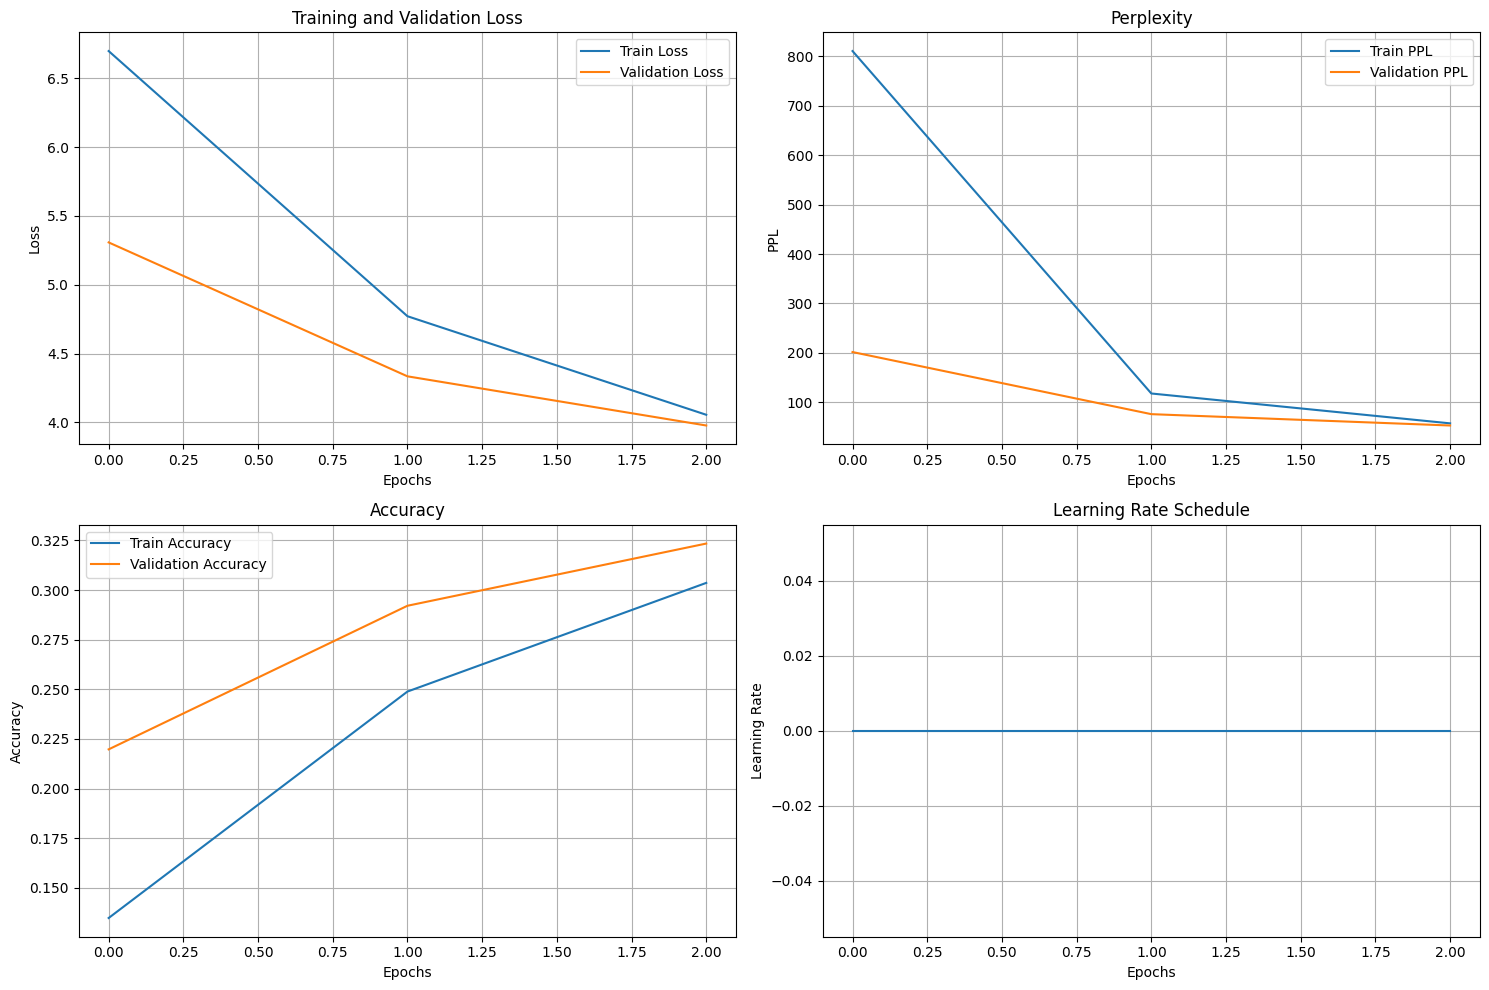

Final model saved to best_model.pth


In [13]:
# ===================== Plot Training Statistics =====================
plt.figure(figsize=(15, 10))

# Loss
plt.subplot(2, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Perplexity
plt.subplot(2, 2, 2)
plt.plot(train_ppls, label='Train PPL')
plt.plot(val_ppls, label='Validation PPL')
plt.title('Perplexity')
plt.xlabel('Epochs')
plt.ylabel('PPL')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(2, 2, 3)
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Learning Rate
plt.subplot(2, 2, 4)
lr_history = [optimizer.param_groups[0]['lr'] for _ in range(len(train_losses))]
plt.plot(lr_history)
plt.title('Learning Rate Schedule')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')
plt.show()

print("Final model saved to best_model.pth")

In [ ]:
def save_training_state(epoch, model, optimizer, scheduler,
                        train_losses, val_losses, train_ppls, val_ppls, train_accs, val_accs,
                        checkpoint_dir="checkpoints", is_best=False):
    os.makedirs(checkpoint_dir, exist_ok=True)

    # Save main checkpoint
    checkpoint_path = os.path.join(checkpoint_dir, f"checkpoint_epoch_{epoch+1}.pth")
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.cpu().state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_ppls': train_ppls,
        'val_ppls': val_ppls,
        'train_accs': train_accs,
        'val_accs': val_accs,
    }, checkpoint_path)
    model.to(device)

    # Save best model if flagged
    if is_best:
        torch.save(model.state_dict(), os.path.join(checkpoint_dir, "best_model.pth"))
        print("✅ Best model updated.")

    # Save tokenizer
    if hasattr(tokenizer, "save_pretrained"):
        tokenizer.save_pretrained(checkpoint_dir)
    else:
        tokenizer.save(os.path.join(checkpoint_dir, "tokenizer.json"))

    # Save config
    config = {
        'D_MODEL': D_MODEL, 'D_K': D_K, 'FF_DIM': FF_DIM,
        'NUM_LAYERS': NUM_LAYERS, 'VOCAB_SIZE': VOCAB_SIZE,
        'SEQ_LEN': SEQ_LEN, 'BATCH_SIZE': BATCH_SIZE,
        'LR': LR, 'DROPOUT': DROPOUT, 'WEIGHT_DECAY': WEIGHT_DECAY,
        'GRAD_CLIP': GRAD_CLIP, 'WARMUP_STEPS': WARMUP_STEPS,
        'GRAD_ACCUM_STEPS': GRAD_ACCUM_STEPS, 'GRAD_CHECKPOINT': GRAD_CHECKPOINT,
        'CONV_SPECIAL_TOKENS': CONV_SPECIAL_TOKENS,
    }
    with open(os.path.join(checkpoint_dir, "config.json"), 'w') as f:
        json.dump(config, f, indent=2)

    print(f"Training state saved to {checkpoint_dir} at epoch {epoch+1}")


In [18]:
save_training_state(
    epoch=3,                 # last epoch index (0-based)
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    train_losses=train_losses,
    val_losses=val_losses,
    train_ppls=train_ppls,
    val_ppls=val_ppls,
    train_accs=train_accs,
    val_accs=val_accs,
    checkpoint_dir="trained_model_save"  # <-- your folder name
)


💾 Training state saved to trained_model_save at epoch 4
